<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Maria_HeartCycle_FILTEREDDATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FILTERED ICG**


Aplicando un filtrado adaptativo y paso banda:

<class 'numpy.ndarray'>
(1, 1)


<ipython-input-1-30df5f934786>:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  senal_filtrada[i] = error


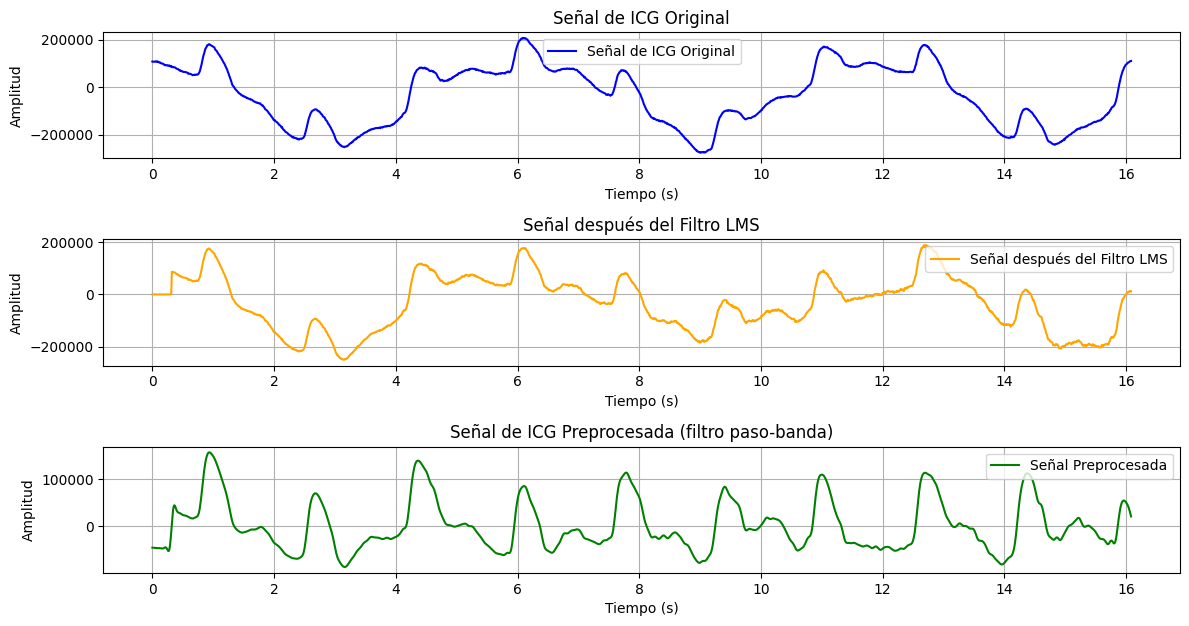

In [ ]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

#from google.colab import files
# Upload the file from your local machine
#uploaded = files.upload()

filename = f'/content/59146237_s0000008.mat'
data_raw_HC =  sio.loadmat(filename)

#print(data_raw_HC.keys())
measures= data_raw_HC['measure']
#print(measures)
impedance=measures[1,1]
#print(impedance)
impedance_time=impedance['time']
#print(impedance_time)
impedance_data=impedance['data']
#print(impedance_data)
print(type(impedance_data))
print(impedance_data.shape) #impedance data is a 2D array

impedance_data_value = impedance_data[0, 0] #all the data is stored in [0,0]
impedance_data_value = impedance_data_value[0:1608]


from scipy.signal import butter, filtfilt

# Supongamos que ya tienes la señal de ICG en la variable `impedance`
# impedance = np.array(...)  # Tu señal de ICG

# Generar una señal de referencia (simulada, ajusta según tu caso)
# La señal de referencia debe estar correlacionada con el ruido o los artefactos de movimiento.
# Por ejemplo, puedes usar una señal de acelerómetro o crear una señal sintética.
np.random.seed(0)
tiempo = np.linspace(0, len(impedance_data_value) / 100, len(impedance_data_value))  # Vector de tiempo (ajusta la frecuencia de muestreo)
senal_referencia = 0.1 * np.sin(2 * np.pi * 0.2 * tiempo) + 0.05 * np.random.normal(size=len(impedance_data_value))

# Filtro Adaptativo LMS
def filtro_lms(impedance_data_value, senal_referencia, tasa_aprendizaje=0.01, orden_filtro=32):

    #Filtro adaptativo LMS para eliminar el ruido y los artefactos de movimiento.

    n_muestras = len(impedance_data_value)
    coeficientes = np.zeros(orden_filtro)  # Coeficientes del filtro
    senal_filtrada = np.zeros(n_muestras)  # Señal filtrada

    for i in range(orden_filtro, n_muestras):
        # Ventana de la señal de referencia
        ventana_referencia = senal_referencia[i - orden_filtro:i]
        # Estimación de la señal contaminada
        estimacion = np.dot(coeficientes, ventana_referencia)
        # Error entre la señal contaminada y la estimación
        error = impedance_data_value[i] - estimacion
        # Actualización de los coeficientes del filtro
        coeficientes += tasa_aprendizaje * error * ventana_referencia
        # Almacenar la señal filtrada
        senal_filtrada[i] = error

    return senal_filtrada

# Aplicar el filtro LMS a la señal de ICG
tasa_aprendizaje = 0.01  # Tasa de aprendizaje del filtro LMS
orden_filtro = 32  # Orden del filtro LMS
senal_filtrada_lms = filtro_lms(impedance_data_value, senal_referencia, tasa_aprendizaje, orden_filtro)

def filtro_pasa_banda(impedance_data_value, frecuencia_corte_baja, frecuencia_corte_alta, frecuencia_muestreo, orden=4):

    #Filtro pasa-banda para aislar las frecuencias relevantes de la ICG.

    # Diseñar el filtro pasa-banda
    b, a = butter(orden, [frecuencia_corte_baja / (frecuencia_muestreo / 2), frecuencia_corte_alta / (frecuencia_muestreo / 2)], btype='band')
    return filtfilt(b, a, impedance_data_value)

frecuencia_corte_baja = 0.5  # Frecuencia de corte inferior (Hz)
frecuencia_corte_alta = 20  # Frecuencia de corte superior (Hz)
frecuencia_muestreo = 200
senal_filtrada = filtro_pasa_banda(senal_filtrada_lms, frecuencia_corte_baja, frecuencia_corte_alta, frecuencia_muestreo)

#def eliminar_linea_base(impedance_data_value, frecuencia_corte_baja, frecuencia_muestreo, orden=4):
#He comentado todo esto pq al final era aplicar un filtrado paso alto a una frecuencia de 0.5 que eso ya lo incluye el filtro paso banda

    #Filtro pasa-altos para eliminar la línea base.

    #b, a = butter(orden, frecuencia_corte_baja / (frecuencia_muestreo / 2), btype='high')
    #return filtfilt(b, a, impedance_data_value)

#frecuencia_corte_baja = 0.5  # Frecuencia de corte para eliminar la línea base (Hz)
#senal_sin_linea_base = eliminar_linea_base(senal_filtrada, frecuencia_corte_baja, frecuencia_muestreo)


# Graficar las señales
plt.figure(figsize=(12, 8))

# Señal original
plt.subplot(4, 1, 1)
plt.plot(tiempo, impedance_data_value, label='Señal de ICG Original', color='blue')
plt.title('Señal de ICG Original')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Señal después del filtro LMS
plt.subplot(4, 1, 2)
plt.plot(tiempo, senal_filtrada_lms, label='Señal después del Filtro LMS', color='orange')
plt.title('Señal después del Filtro LMS')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Señal preprocesada (después del filtro paso banda)
plt.subplot(4, 1, 3)
plt.plot(tiempo, senal_filtrada, label='Señal Preprocesada', color='green')
plt.title('Señal de ICG Preprocesada (filtro paso-banda)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Señal preprocesada (después de eliminar la línea base)
#plt.subplot(4, 1, 4)
#plt.plot(tiempo, senal_sin_linea_base, label='Señal Preprocesada', color='pink')
#plt.title('Señal de ICG Preprocesada (eliminación línea base)')
#plt.xlabel('Tiempo (s)')
#plt.ylabel('Amplitud')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

Aplicamos el filtrado adaptativo, SG y de supresión de la línea base

<class 'numpy.ndarray'>
(1, 1)


<ipython-input-2-af3c59a204a7>:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  senal_filtrada[i] = error


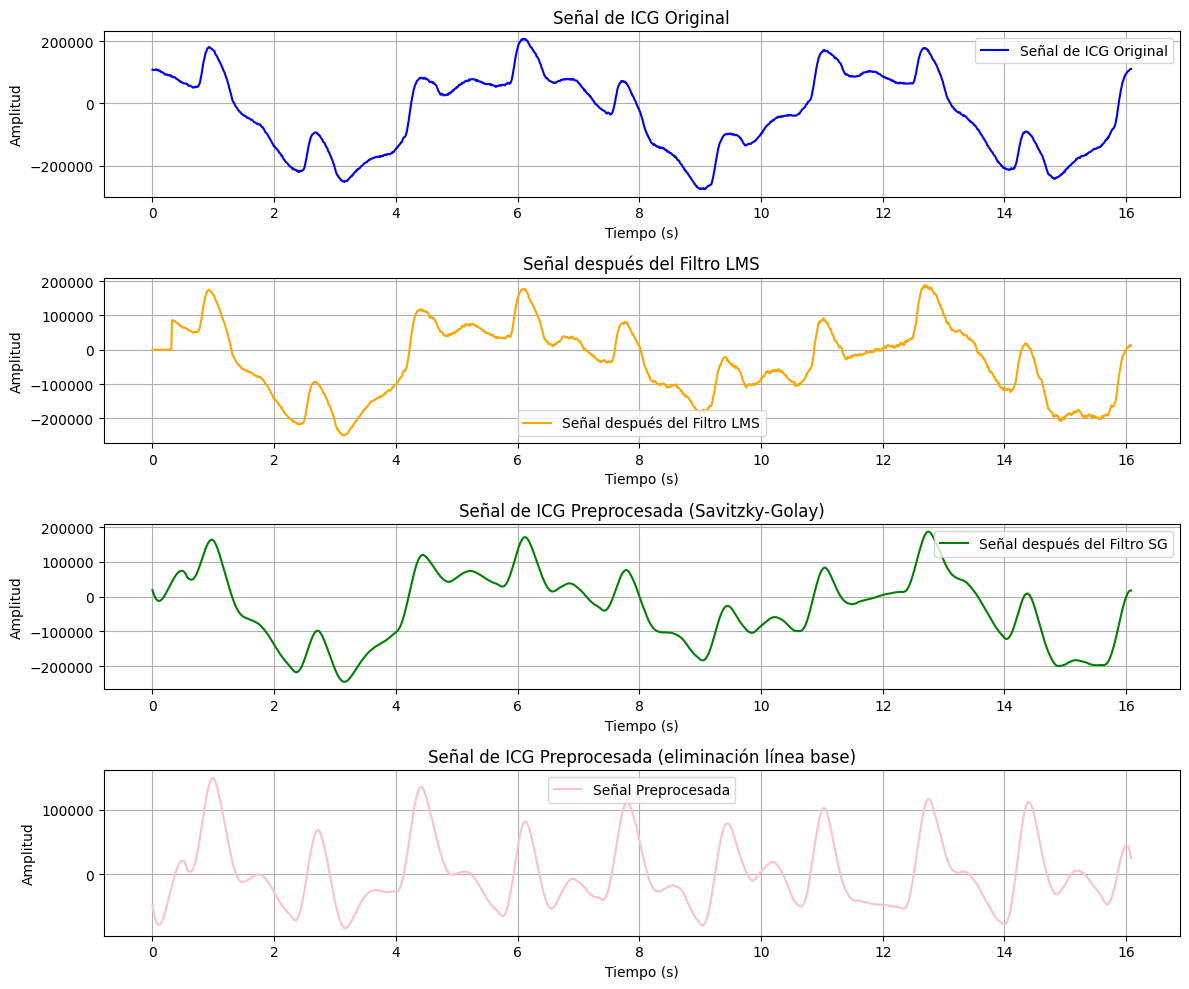

In [ ]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter  # Importamos la función específica para SG

# Cargar los datos
filename = f'/content/59146237_s0000008.mat'
data_raw_HC = sio.loadmat(filename)
measures = data_raw_HC['measure']
impedance = measures[1,1]
impedance_time = impedance['time']
impedance_data = impedance['data']
print(type(impedance_data))
print(impedance_data.shape)  # Verificamos la forma de los datos

# Extraer los valores de impedancia
impedance_data_value = impedance_data[0, 0]  # Todos los datos están en [0,0]
impedance_data_value = impedance_data_value[0:1608]  # Tomamos un segmento

# Crear vector de tiempo (asumiendo fs=100Hz)
tiempo = np.linspace(0, len(impedance_data_value)/100, len(impedance_data_value))

# Generar señal de referencia (simulada)
np.random.seed(0)
senal_referencia = 0.1 * np.sin(2 * np.pi * 0.2 * tiempo) + 0.05 * np.random.normal(size=len(impedance_data_value))

# Filtro Adaptativo LMS (se mantiene igual)
def filtro_lms(impedance_data_value, senal_referencia, tasa_aprendizaje=0.01, orden_filtro=32):
    n_muestras = len(impedance_data_value)
    coeficientes = np.zeros(orden_filtro)
    senal_filtrada = np.zeros(n_muestras)

    for i in range(orden_filtro, n_muestras):
        ventana_referencia = senal_referencia[i - orden_filtro:i]
        estimacion = np.dot(coeficientes, ventana_referencia)
        error = impedance_data_value[i] - estimacion
        coeficientes += tasa_aprendizaje * error * ventana_referencia
        senal_filtrada[i] = error

    return senal_filtrada

# Aplicar filtro LMS
tasa_aprendizaje = 0.01
orden_filtro = 32
senal_filtrada_lms = filtro_lms(impedance_data_value, senal_referencia, tasa_aprendizaje, orden_filtro)

## NUEVO: Implementación del Filtro Savitzky-Golay
def filtro_savgol(senal, window_length=51, polyorder=3):

    return savgol_filter(senal, window_length, polyorder)

# Aplicar filtro SG con parámetros recomendados para ICG
window_length = 51  # Longitud de ventana (debe ser impar)
polyorder = 3  # Orden del polinomio (2 o 3)
senal_filtrada_sg = filtro_savgol(senal_filtrada_lms, window_length, polyorder)

def eliminar_linea_base(impedance_data_value, frecuencia_corte_baja, frecuencia_muestreo, orden=4):

    #Filtro pasa-altos para eliminar la línea base.

    b, a = butter(orden, frecuencia_corte_baja / (frecuencia_muestreo / 2), btype='high')
    return filtfilt(b, a, impedance_data_value)

frecuencia_corte_baja = 0.5  # Frecuencia de corte para eliminar la línea base (Hz)
frecuencia_muestreo = 200
senal_sin_linea_base = eliminar_linea_base(senal_filtrada_sg, frecuencia_corte_baja, frecuencia_muestreo)


# Graficar las señales
plt.figure(figsize=(12, 10))

# Señal original
plt.subplot(4, 1, 1)
plt.plot(tiempo, impedance_data_value, label='Señal de ICG Original', color='blue')
plt.title('Señal de ICG Original')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Señal después del filtro LMS
plt.subplot(4, 1, 2)
plt.plot(tiempo, senal_filtrada_lms, label='Señal después del Filtro LMS', color='orange')
plt.title('Señal después del Filtro LMS')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Señal después del filtro SG
plt.subplot(4, 1, 3)
plt.plot(tiempo, senal_filtrada_sg, label='Señal después del Filtro SG', color='green')
plt.title('Señal de ICG Preprocesada (Savitzky-Golay)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

#Señal después de la supresión de la línea base
plt.subplot(4, 1, 4)
plt.plot(tiempo, senal_sin_linea_base, label='Señal Preprocesada', color='pink')
plt.title('Señal de ICG Preprocesada (eliminación línea base)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()



Now that we have the ICG signal filtered, we are going to hold on to it some calculated parameters that have been provided

We focus on plotting **PreEjection period**

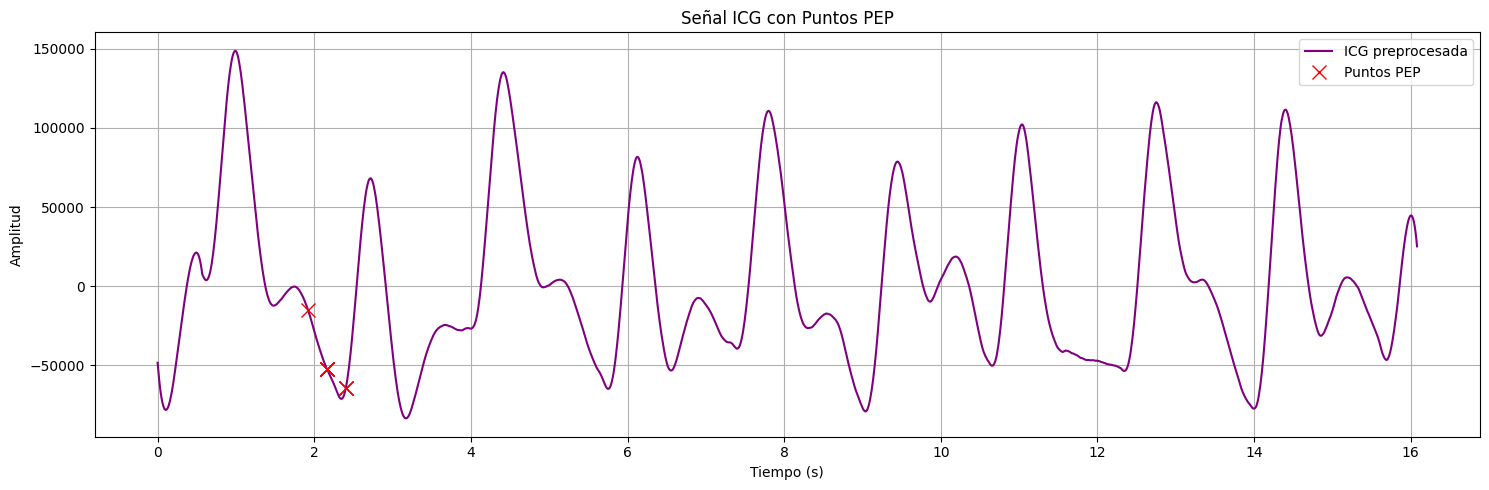

In [ ]:
# Extraer PEP
PEP = measures[4, 1]
PEP_time = PEP['time']
PEP_data = PEP['data']
PEP_data_value = PEP_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de PEP a índices de muestra
frecuencia_muestreo=200
PEP_sample_indices = (PEP_data_value.flatten() * frecuencia_muestreo).astype(int)

# Obtener amplitudes de la señal preprocesada en los puntos PEP
PEP_amplitudes = senal_sin_linea_base[PEP_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, senal_sin_linea_base, label='ICG preprocesada', color='purple')
plt.plot(tiempo[PEP_sample_indices], PEP_amplitudes, 'rx', markersize=10, label='Puntos PEP')
plt.title('Señal ICG con Puntos PEP')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


We focus on plotting **Time of aortic valve opening**

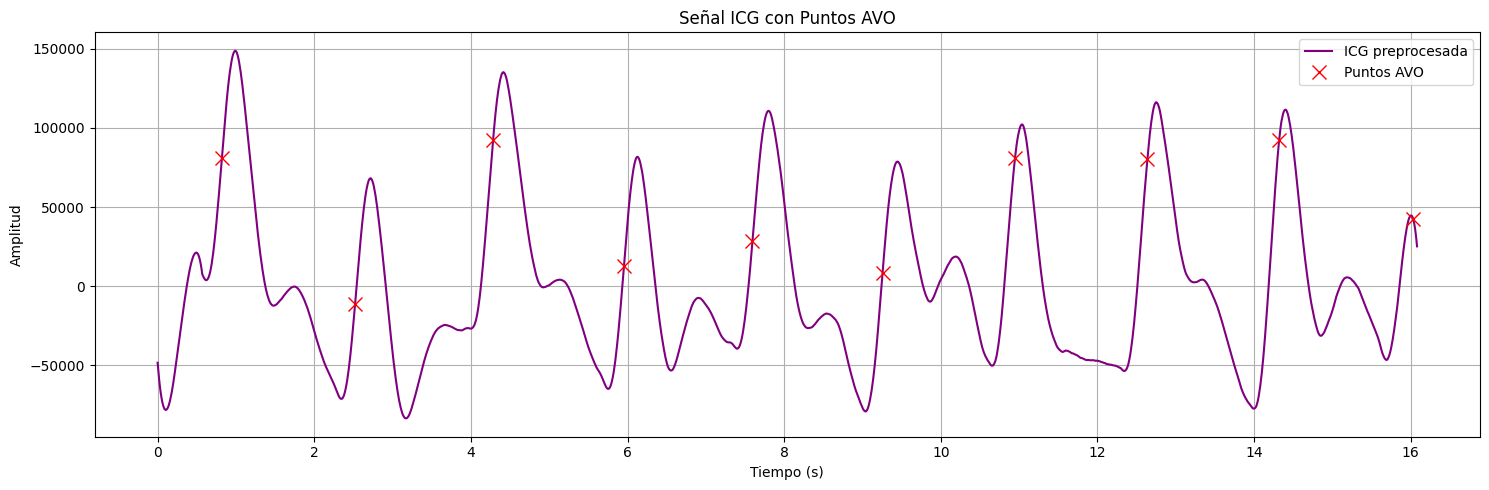

In [ ]:
# Extraer AVO
AVO = measures[3, 1]
AVO_time = AVO['time']
AVO_data = AVO['data']
AVO_data_value = AVO_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de AVO a índices de muestra
frecuencia_muestreo=200
AVO_sample_indices = (AVO_data_value.flatten() * frecuencia_muestreo).astype(int)
AVO_sample_indices = AVO_sample_indices[AVO_sample_indices < len(senal_sin_linea_base)]

# Obtener amplitudes de la señal preprocesada en los puntos PEP
AVO_amplitudes = senal_sin_linea_base[AVO_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, senal_sin_linea_base, label='ICG preprocesada', color='purple')
plt.plot(tiempo[AVO_sample_indices], AVO_amplitudes, 'rx', markersize=10, label='Puntos AVO')
plt.title('Señal ICG con Puntos AVO')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Maybe it can appear on other patient but not on this one

We focus on plotting **Time of aortic valve closure**

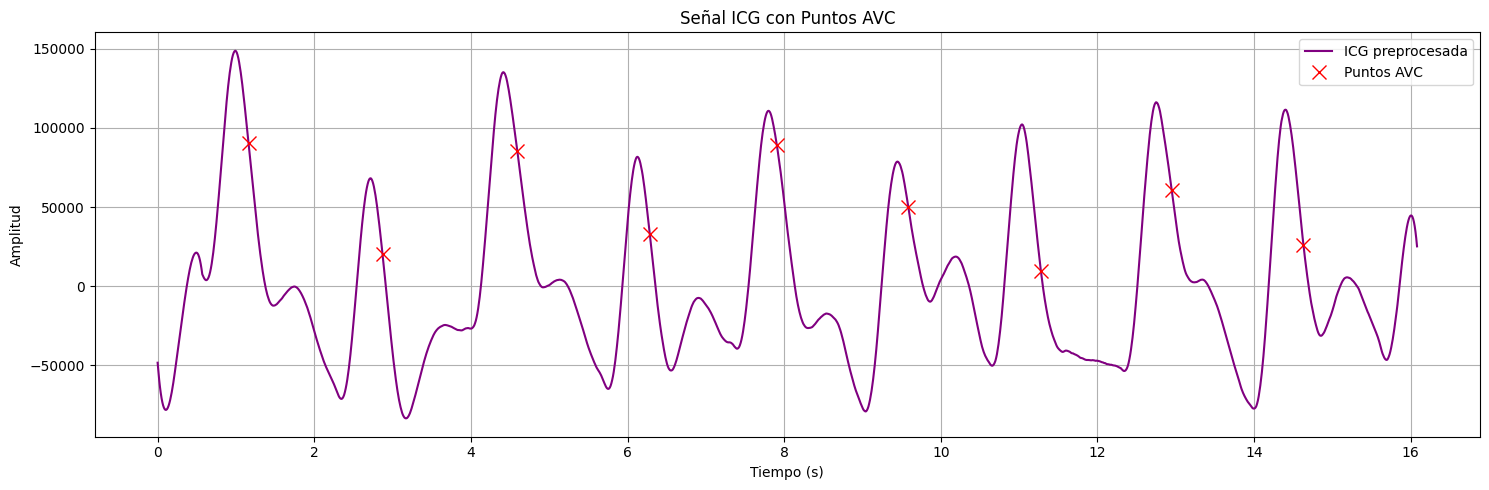

In [ ]:
AVC = measures[5, 1]
AVC_time = AVC['time']
AVC_data = AVC['data']
AVC_data_value = AVC_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de AVO a índices de muestra
frecuencia_muestreo=200
AVC_sample_indices = (AVC_data_value.flatten() * frecuencia_muestreo).astype(int)
AVC_sample_indices = AVC_sample_indices[AVC_sample_indices < len(senal_sin_linea_base)]

# Obtener amplitudes de la señal preprocesada en los puntos PEP
AVC_amplitudes = senal_sin_linea_base[AVC_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, senal_sin_linea_base, label='ICG preprocesada', color='purple')
plt.plot(tiempo[AVC_sample_indices], AVC_amplitudes, 'rx', markersize=10, label='Puntos AVC')
plt.title('Señal ICG con Puntos AVC')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

We focus on plotting **Left Ventricle Ejection Time**

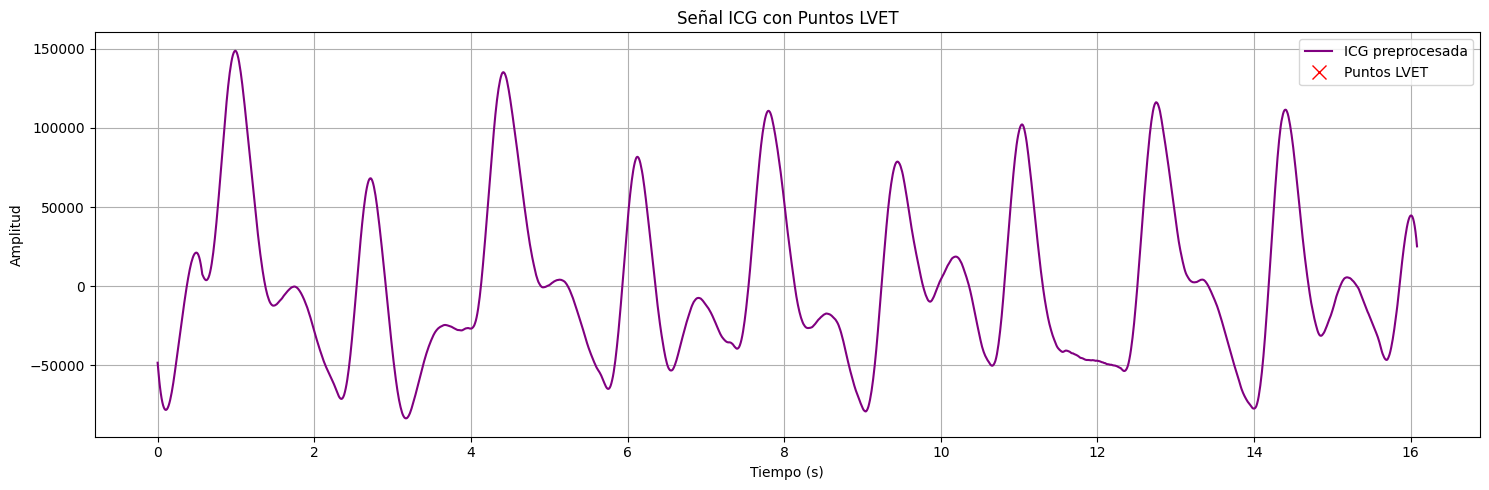

In [ ]:
# Extraer LVET
LVET = measures[6, 1]
LVET_time = LVET['time']
LVET_data = LVET['data']
LVET_data_value = LVET_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de PEP a índices de muestra
frecuencia_muestreo=200
LVET_sample_indices = (LVET_data_value.flatten() * frecuencia_muestreo).astype(int)
LVET_sample_indices = LVET_sample_indices[LVET_sample_indices < len(senal_sin_linea_base)]

# Obtener amplitudes de la señal preprocesada en los puntos PEP
LVET_amplitudes = senal_sin_linea_base[LVET_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, senal_sin_linea_base, label='ICG preprocesada', color='purple')
plt.plot(tiempo[LVET_sample_indices], LVET_amplitudes, 'rx', markersize=10, label='Puntos LVET')
plt.title('Señal ICG con Puntos LVET')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()